<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/Loan_Default_Prediction_System_data_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("/content/drive/MyDrive/loan_data (1).csv")
df


,person_age,person_income,person_emp_length,person_home_ownership,loan_amnt,loan_intent,loan_grade,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file,loan_status
0,39,32627,0.3,MORTGAGE,5511,EDUCATION,D,9.87,0.17,21,N,1
1,33,40810,21.3,RENT,14469,DEBTCONSOLIDATION,D,8.91,0.35,17,N,0
2,41,34254,8.0,MORTGAGE,2222,DEBTCONSOLIDATION,A,5.00,0.06,24,N,1
3,50,52378,10.2,MORTGAGE,1733,HOMEIMPROVEMENT,A,5.00,0.03,28,N,1
4,32,100539,5.9,MORTGAGE,6380,DEBTCONSOLIDATION,D,8.87,0.06,13,Y,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,48,61864,11.2,OWN,11044,MEDICAL,E,11.88,0.18,29,N,1
9996,18,112018,NaN,RENT,2223,MEDICAL,E,11.89,0.02,0,Y,1
9997,27,61513,6.7,RENT,14479,MEDICAL,D,9.42,0.24,12,N,1
9998,39,137052,4.9,RENT,12506,DEBTCONSOLIDATION,C,6.71,0.09,23,Y,1


In [4]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_grade',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'cb_person_default_on_file', 'loan_status'],
      dtype='object')

In [5]:
df.isnull().any()

,0
person_age,False
person_income,False
person_emp_length,True
person_home_ownership,False
loan_amnt,False
loan_intent,False
loan_grade,False
loan_int_rate,False
loan_percent_income,False
cb_person_cred_hist_length,False


In [6]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
1,0.6327
0,0.3673


<Axes: xlabel='loan_status', ylabel='count'>

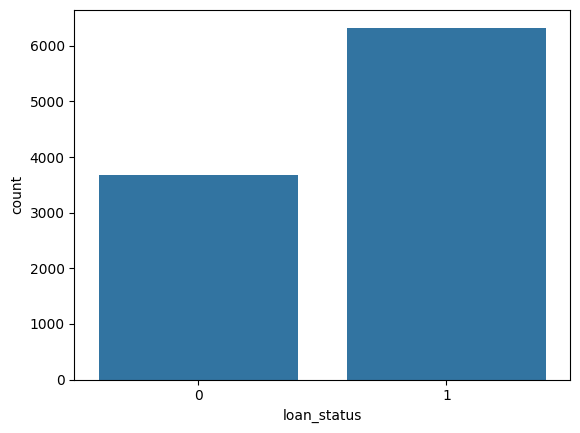

In [7]:
sns.countplot(data=df ,  x='loan_status')

by seeing the distribution we can see that there is a minor class imbalance with 63:36 ratio , how ever it is not extreme

<Axes: xlabel='person_age', ylabel='Count'>

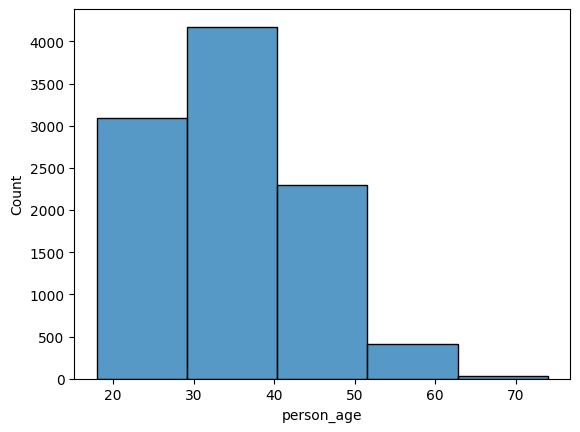

In [8]:
sns.histplot(data=df, x='person_age',bins=5)

<Axes: xlabel='loan_amnt'>

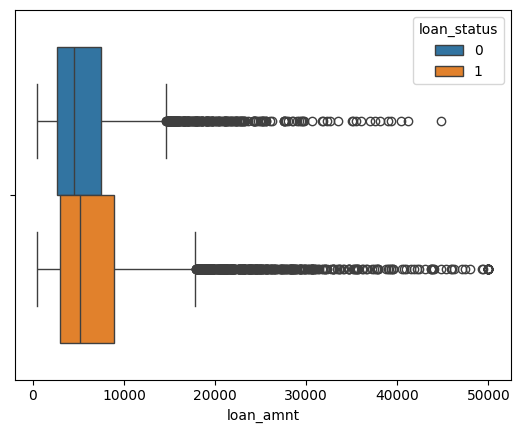

In [9]:
num_column=df.select_dtypes(include='number').columns.to_list()
sns.boxplot(data=df,x='loan_amnt',hue='loan_status')

we can see that the midian of loan_status=1(defaulters) have a a bit higher median then non defaulters which tells people who take higher loan amount are more likely to be defaulters, moreover we can see distributions overlaps loan_amnt isnt the strong pradictor

In [10]:
df['person_emp_length'].isnull().sum()

np.int64(497)

<Axes: xlabel='person_emp_length'>

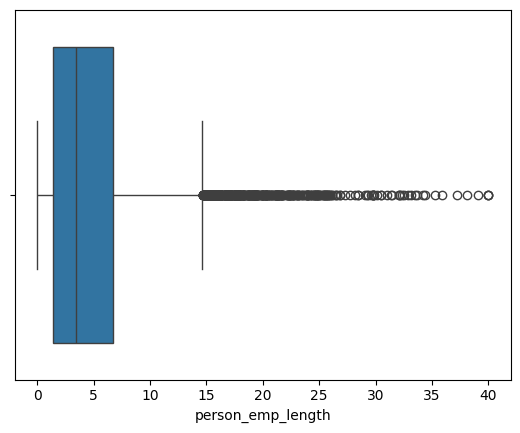

In [11]:
sns.boxplot(data=df, x='person_emp_length')

In [12]:
df['loan_percent_income'].describe()

,loan_percent_income
count,10000.000000
mean,0.158880
std,0.176749
min,0.000000
25%,0.050000
50%,0.100000
75%,0.200000
max,1.000000


<Axes: xlabel='loan_percent_income', ylabel='Count'>

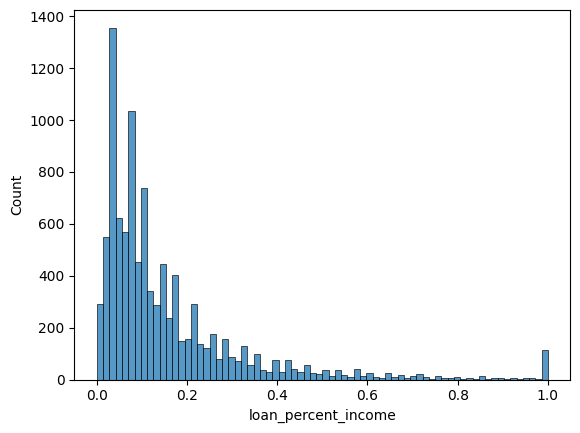

In [13]:
sns.histplot(data=df, x='loan_percent_income')

In [14]:
df["loan_percent_income"].corr(df["person_income"])

np.float64(-0.39754805007683963)

Moderate negative correlation (-0.40). As income increases, the loan-to-income ratio decreases — higher earners borrow a smaller fraction of their income relative to lower earners.

In [15]:
df.sort_values(by='loan_percent_income', ascending=False).head(20)

,person_age,person_income,person_emp_length,person_home_ownership,loan_amnt,loan_intent,loan_grade,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file,loan_status
9125,35,21960,0.6,MORTGAGE,35147,DEBTCONSOLIDATION,F,14.58,1.0,18,N,0
4430,18,18192,2.0,MORTGAGE,22676,PERSONAL,G,17.92,1.0,2,Y,1
4428,36,31021,0.1,RENT,33503,MEDICAL,A,5.00,1.0,17,N,0
3367,36,12688,3.5,RENT,14189,VENTURE,C,6.66,1.0,18,N,1
8963,32,17893,10.1,OWN,45865,HOMEIMPROVEMENT,F,15.63,1.0,11,N,1
3326,34,11907,1.5,MORTGAGE,13543,MEDICAL,A,5.00,1.0,14,N,1
4455,37,13123,2.7,OWN,17075,PERSONAL,C,8.15,1.0,15,N,0
4604,24,13630,1.4,MORTGAGE,16568,DEBTCONSOLIDATION,B,5.68,1.0,6,N,0
4145,18,15384,4.5,MORTGAGE,24336,VENTURE,B,5.24,1.0,1,N,1
4127,52,21636,0.8,MORTGAGE,45326,HOMEIMPROVEMENT,D,11.00,1.0,30,Y,1


In [16]:
df['person_income'].median()

49488.5

approx 115 people have exactly 1.0 **loan_percent_income** means the loan is 100% of there yearly income. And we can also see that people having **loan_percent_income** >0.80 have low  annual income , as 50% of the total people have income more then 50k , but people having **loan_percent_income** >0.80 ranges between 10K-30K

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

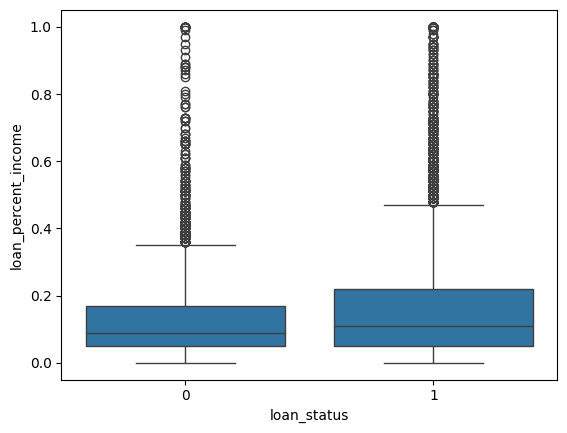

In [17]:
sns.boxplot(data=df, x='loan_status', y='loan_percent_income')

From the above boxplot we can observe that  defaulters tend to ave higher medain loan_percent_income then non defaulters, here feature **loan_percent_income** can play a quite good role in pradicting **loan_status**

In [18]:
df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,8451
Y,1549


In [19]:
ct=pd.crosstab(df['cb_person_default_on_file'], df['loan_status'], normalize='index')
ct

loan_status,0,1
cb_person_default_on_file,,
N,0.388238,0.611762
Y,0.253066,0.746934


Text(70.72222222222221, 0.5, 'cb_person_default_on_file')

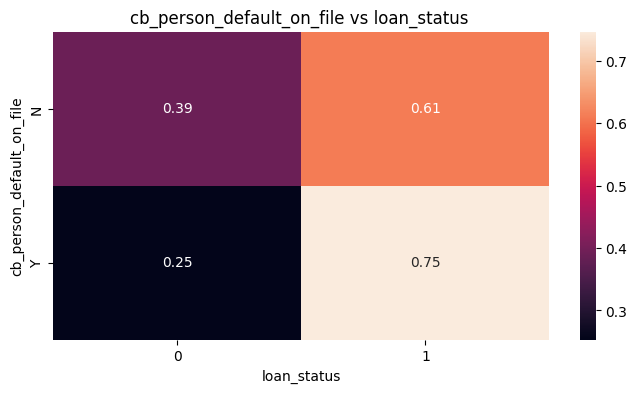

In [20]:
plt.figure(figsize=(8,4))
sns.heatmap(ct,annot=True)
plt.title("cb_person_default_on_file vs loan_status ")
plt.xlabel("loan_status")
plt.ylabel("cb_person_default_on_file")

One of the most significant observations is that the **cb_person_default_on_file** feature, which indicates whether a customer has previously defaulted on a loan, shows a strong relationship with the target variable. Customers with a history of default are considerably more likely to default again, whereas those with no previous default history are much less likely to default. This suggests that **cb_person_default_on_file** is a strong predictor of loan default and is likely to contribute significantly to the model's predictive performance.


In [21]:
df['person_income'].describe()

,person_income
count,10000.000000
mean,59177.512900
std,38960.732065
min,10000.000000
25%,32951.500000
50%,49488.500000
75%,74332.750000
max,500000.000000


<Axes: xlabel='person_income', ylabel='Count'>

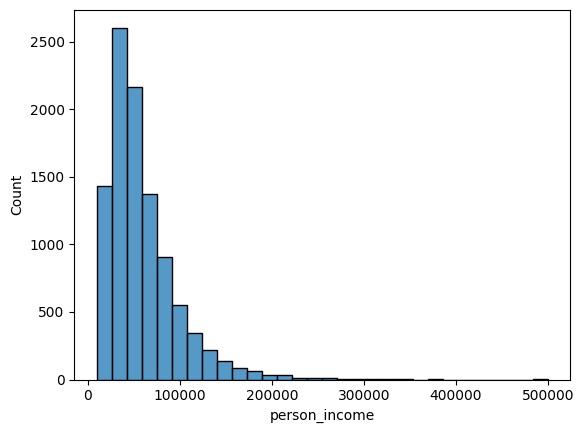

In [22]:
sns.histplot(data=df , x='person_income',bins=30)

 It means incomes are widely spread — most people(roughly 68%)fall within roughly 20k to 100K (1st std), but the max of $500k shows there are wealthy outliers pulling the std up. The data is right-skewed , where median< mean

<Axes: xlabel='loan_amnt', ylabel='person_income'>

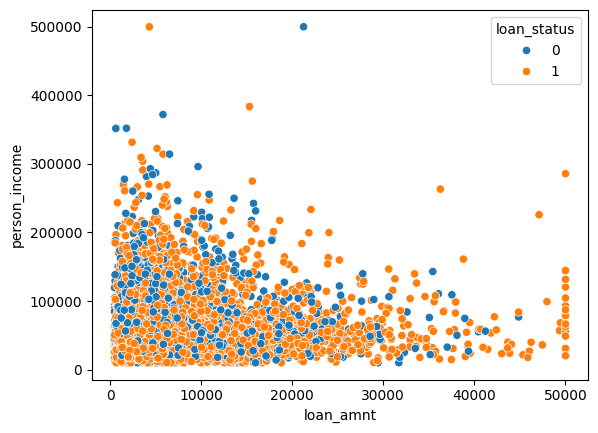

In [23]:
sns.scatterplot(data=df, x='loan_amnt', y='person_income',hue='loan_status')

In [24]:
import joblib

# Load the pipeline
pipeline = joblib.load("/content/drive/MyDrive/loan_model_pipeline.pkl")

# See what's inside
print(pipeline)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols='deprecated',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                            

/usr/lib/python3.12/pickle.py:1760: UserWarning: [18:26:10] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


## DATA PREPROCESSING

In [25]:
input=df.drop(labels='loan_status',axis=1)
output=df['loan_status']

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    input, output, test_size=0.30, random_state=42)

In [27]:
input_numeric_column=X_train.select_dtypes(include='number').columns.to_list()
input_cat_column=X_train.select_dtypes(include='object').columns.to_list()
X_train[input_cat_column].index


Index([9069, 2603, 7738, 1579, 5058, 5753, 3548,  409, 4097, 6461,
       ...
       8322, 5578, 4426,  466, 6265, 5734, 5191, 5390,  860, 7270],
      dtype='int64', length=7000)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import xgboost as xgb



In [29]:
numeric_pipeline=Pipeline([('imputer', SimpleImputer(strategy='median')),
                           'scaler', StandardScaler()])

categorical_pipeline=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
                               ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                               ])

In [30]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,input_numeric_column),
    ('cat', categorical_pipeline,input_cat_column ),
])


In [31]:
pipeline=Pipeline([
    ('preprocessor', preprocessor),
    ('model',xgb.XGBClassifier(random_state=42))
])

In [32]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.9 MB/s eta 0:00:00


In [33]:
import optuna

In [34]:
from sklearn.model_selection import cross_val_score

In [35]:
def objective(trial):
  params={
      'classifier_n_estimators':trial.suggest_int('n_estimators',50,500,step=50),
      'classifier__max_depth':trial.suggest_int('max_depth', 3,10),
      'classifier_min_child_weight':trial.suggest_int('min_child_weight',1,15),
      'classifier_gamma':trial.suggest_int('gamma',0,6),
      'classifier__subsample':trial.suggest_int('subsample',0.5,1.0),
      'classifier__colsample_bytree':trial.suggest_int('colsample_bytree',0.4,1.0)

  }
  pipeline.set_params(**params)
  score=cross_val_score(pipeline,X_train,y_train,cv=5,scoring='roc_auc').mean()
  return score


In [36]:
study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=100)

[I 2026-06-25 18:26:18,832] A new study created in memory with name: no-name-bd91b578-78fb-4d00-90ef-474febe2c77c
[W 2026-06-25 18:26:18,858] Trial 0 failed with parameters: {'n_estimators': 200, 'max_depth': 10, 'min_child_weight': 12, 'gamma': 3, 'subsample': 1, 'colsample_bytree': 0} because of the following error: ValueError("Invalid parameter 'classifier_n_estimators' for estimator Pipeline(steps=[('preprocessor',\n                 ColumnTransformer(transformers=[('num',\n                                                  Pipeline(steps=[('imputer',\n                                                                   SimpleImputer(strategy='median')),\n                                                                  'scaler',\n                                                                  StandardScaler()]),\n                                                  ['person_age',\n                                                   'person_income',\n                                     

ValueError: Invalid parameter 'classifier_n_estimators' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  'scaler',
                                                                  StandardScaler()]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat'